In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import umap
import warnings
import timeit
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scipy.stats as stats

C:\Users\thami\Documents\GitHub\TCC agrupamento\agrupamento-tcc\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
warnings.filterwarnings("ignore", message="n_jobs value 1 overridden to 1 by setting random_state")

### Leitura de dados

In [3]:
df = pd.read_csv('../dados_processados/cursos-pos-processamento.csv',sep=';')

In [4]:
df_scaled = df.drop(['no_curso','co_curso'],axis=1)

### Funções

In [5]:
barnes_hut = 'barnes_hut'
exact = 'exact'
n_neighbors = 5
min_dist = 0.1
random_state = 42

In [6]:
def reduzir_dimensionalidade_PCA(n_components):
    #Reduzir dimensionalidade com PCA
    pca = PCA(n_components=n_components, random_state=random_state)
    data_pca = pca.fit_transform(df_scaled)

    return data_pca

In [7]:
def reduzir_dimensionalidade_t_sne(n_components, perplexity, method):
    #Reduzir dimensionalidade com t-SNE
    tsne = TSNE(n_components=n_components, perplexity=perplexity, random_state=random_state, method=method)
    data_tsne = tsne.fit_transform(df_scaled)

    return data_tsne

In [8]:
def reduzir_dimensionalidade_UMAP(n_components, n_neighbors, min_dist):
    #Reduzir dimensionalidade com UMAP
    umap_model = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, n_components=n_components, metric='euclidean', random_state=random_state)
    data_umap = umap_model.fit_transform(df_scaled)

    return data_umap

### Função coleta de tempos

In [9]:
def coletar_tempos_execucao(componentes, n_execucoes=50):
    """
    Coleta os tempos de execução dos métodos PCA, t-SNE e UMAP.
    
    Retorna:
    - dicionário com listas de tempos por método
    """
    tempos = {
        'PCA': [timeit.timeit(lambda: reduzir_dimensionalidade_PCA(componentes), number=1) for _ in range(n_execucoes)],
        't-SNE': [timeit.timeit(lambda: reduzir_dimensionalidade_t_sne(componentes, 40, barnes_hut), number=1) for _ in range(n_execucoes)],
        'UMAP': [timeit.timeit(lambda: reduzir_dimensionalidade_UMAP(componentes, n_neighbors, min_dist), number=1) for _ in range(n_execucoes)],
    }
    return tempos

### Função de análise com ANOVA e TUKEY

In [10]:
def analisar_tempos_estatisticamente(tempos_dict):
    """
    Realiza ANOVA e Tukey HSD a partir de um dicionário de listas de tempos.
    """
    # Transforma o dicionário em DataFrame
    todos_tempos = []
    todos_metodos = []
    for metodo, tempos in tempos_dict.items():
        todos_tempos.extend(tempos)
        todos_metodos.extend([metodo] * len(tempos))
    
    df = pd.DataFrame({
        'tempo': todos_tempos,
        'metodo': todos_metodos
    })
    
    # ANOVA tipo II
    modelo = ols('tempo ~ metodo', data=df).fit()
    anova_tabela = sm.stats.anova_lm(modelo, typ=2)
    
    print("\n ANOVA tipo II:")
    print(anova_tabela)
    
    if anova_tabela['PR(>F)'][0] < 0.05:
        print("\n Diferença significativa encontrada — executando Tukey HSD:")
        tukey = pairwise_tukeyhsd(endog=df['tempo'], groups=df['metodo'], alpha=0.05)
        print(tukey)
        tukey.plot_simultaneous()
        plt.title("Tukey HSD")
        plt.show()
    else:
        print("\n ANOVA não significativa — métodos têm tempos semelhantes.")

### Análise tempo

In [11]:
def calcular_estatisticas(tempos_dict):
    """
    Calcula e exibe média, desvio padrão e IC 95% para cada método.
    Plota gráfico de barras com média e desvio padrão.
    """
    medias = []
    desvios = []
    metodos = []

    for metodo, tempos in tempos_dict.items():
        media = np.mean(tempos)
        desvio = np.std(tempos, ddof=1)
        n = len(tempos)
        erro = stats.sem(tempos)
        intervalo = stats.t.interval(0.95, df=n-1, loc=media, scale=erro)

        print(f"\n Estatísticas para {metodo}:")
        print(f"  Média: {media:.4f} s")
        print(f"  Desvio padrão: {desvio:.4f} s")
        print(f"  IC 95%: ({intervalo[0]:.4f}, {intervalo[1]:.4f}) s")

        metodos.append(metodo)
        medias.append(media)
        desvios.append(desvio)

    # Criando gráfico
    plt.figure(figsize=(8, 5))
    plt.bar(metodos, medias, yerr=desvios, capsize=5, color=['skyblue', 'lightgreen', 'salmon'])
    plt.ylabel("Tempo médio de execução (s)")
    plt.title("Média e Desvio Padrão dos Tempos por Método")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

### Componentes = 2


 Estatísticas para PCA:
  Média: 0.0052 s
  Desvio padrão: 0.0013 s
  IC 95%: (0.0049, 0.0056) s

 Estatísticas para t-SNE:
  Média: 39.8300 s
  Desvio padrão: 2.9845 s
  IC 95%: (38.9818, 40.6782) s

 Estatísticas para UMAP:
  Média: 4.0829 s
  Desvio padrão: 1.9646 s
  IC 95%: (3.5246, 4.6413) s


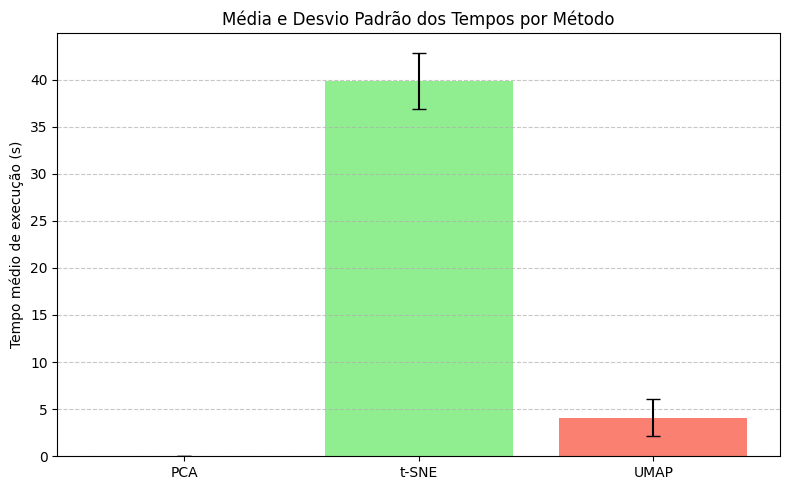


 ANOVA tipo II:
                sum_sq     df            F         PR(>F)
metodo    48008.153830    2.0  5640.688054  1.086329e-139
Residual    625.561859  147.0          NaN            NaN

 Diferença significativa encontrada — executando Tukey HSD:


C:\Users\thami\AppData\Local\Temp\ipykernel_2896\1126471271.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if anova_tabela['PR(>F)'][0] < 0.05:


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
   PCA   UMAP   4.0777   0.0  3.1009  5.0546   True
   PCA  t-SNE  39.8248   0.0 38.8479 40.8016   True
  UMAP  t-SNE   35.747   0.0 34.7702 36.7239   True
---------------------------------------------------


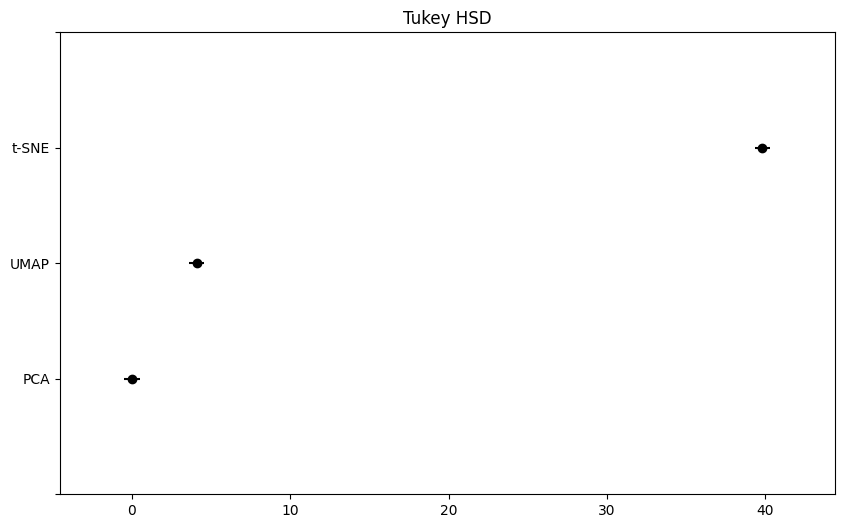

In [12]:
tempos_n_2 = coletar_tempos_execucao(2)
calcular_estatisticas(tempos_n_2)
analisar_tempos_estatisticamente(tempos_n_2)

### Componentes = 3


 Estatísticas para PCA:
  Média: 0.0053 s
  Desvio padrão: 0.0012 s
  IC 95%: (0.0050, 0.0057) s

 Estatísticas para t-SNE:
  Média: 129.7722 s
  Desvio padrão: 0.9886 s
  IC 95%: (129.4913, 130.0532) s

 Estatísticas para UMAP:
  Média: 3.9595 s
  Desvio padrão: 0.1051 s
  IC 95%: (3.9296, 3.9893) s


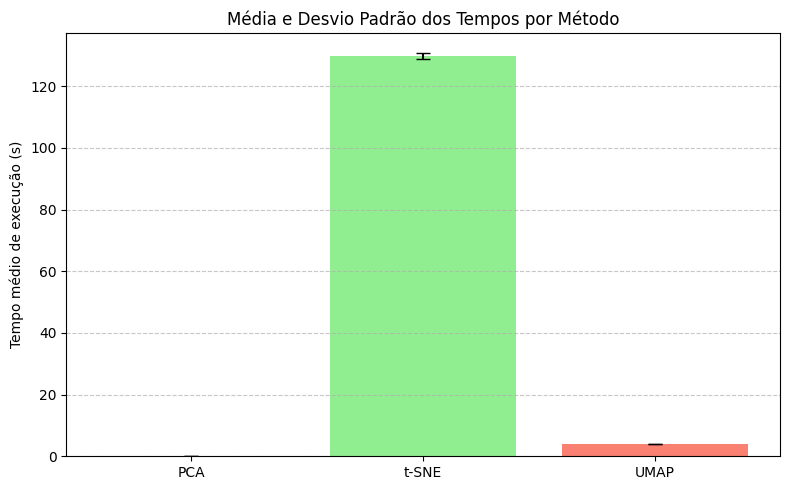


 ANOVA tipo II:
                 sum_sq     df              F         PR(>F)
metodo    544732.124298    2.0  826629.573388  1.765742e-298
Residual      48.435009  147.0            NaN            NaN

 Diferença significativa encontrada — executando Tukey HSD:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj  lower    upper   reject
-----------------------------------------------------
   PCA   UMAP   3.9541   0.0   3.6823    4.226   True
   PCA  t-SNE 129.7669   0.0 129.4951 130.0387   True
  UMAP  t-SNE 125.8127   0.0 125.5409 126.0846   True
-----------------------------------------------------


C:\Users\thami\AppData\Local\Temp\ipykernel_2896\1126471271.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if anova_tabela['PR(>F)'][0] < 0.05:


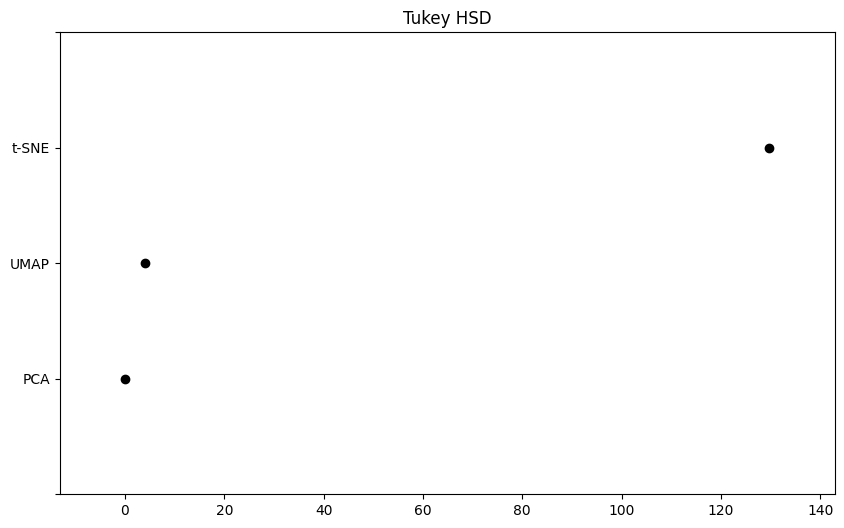

In [13]:
tempos_n_3 = coletar_tempos_execucao(3)
calcular_estatisticas(tempos_n_3)
analisar_tempos_estatisticamente(tempos_n_3)